<a href="https://colab.research.google.com/github/ddisha-07/READMe/blob/main/MentalHealthPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DMW Project Assignment**
PRN: 20240802160, 20240802177, 20240802192


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load CSV file
df = pd.read_csv("mental_health.csv")

# Display first 5 rows
print(df.head())

     Name  Gender  Age Education Level  Screen Time (hrs/day)  \
0   Aarav    Male   15         Class 8                    7.1   
1   Meera  Female   25             MSc                    3.3   
2  Ishaan    Male   20           BTech                    9.5   
3  Aditya    Male   20              BA                   10.8   
4   Anika  Female   17        Class 11                    2.8   

   Sleep Duration (hrs)  Physical Activity (hrs/week) Stress Level  \
0                   8.9                           9.3       Medium   
1                   5.0                           0.2       Medium   
2                   5.4                           6.2       Medium   
3                   5.6                           5.5         High   
4                   5.4                           3.1       Medium   

  Anxious Before Exams Academic Performance Change  
0                   No                        Same  
1                   No                        Same  
2                   No       

In [ ]:
# Display dataset information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Name                          1000 non-null   object 
 1   Gender                        1000 non-null   object 
 2   Age                           1000 non-null   int64  
 3   Education Level               1000 non-null   object 
 4   Screen Time (hrs/day)         1000 non-null   float64
 5   Sleep Duration (hrs)          1000 non-null   float64
 6   Physical Activity (hrs/week)  1000 non-null   float64
 7   Stress Level                  1000 non-null   object 
 8   Anxious Before Exams          1000 non-null   object 
 9   Academic Performance Change   1000 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 78.3+ KB
None


In [ ]:
# Display statistical summary
print(df.describe())

               Age  Screen Time (hrs/day)  Sleep Duration (hrs)  \
count  1000.000000            1000.000000           1000.000000   
mean     20.342000               6.909200              6.450800   
std       3.459914               2.907106              1.466407   
min      15.000000               2.000000              4.000000   
25%      17.000000               4.400000              5.100000   
50%      20.000000               6.900000              6.500000   
75%      23.000000               9.500000              7.700000   
max      26.000000              12.000000              9.000000   

       Physical Activity (hrs/week)  
count                   1000.000000  
mean                       5.017600  
std                        2.930344  
min                        0.000000  
25%                        2.600000  
50%                        5.000000  
75%                        7.600000  
max                       10.000000  


In [ ]:
# Check null values in each column
print(df.isnull().sum())

Name                            0
Gender                          0
Age                             0
Education Level                 0
Screen Time (hrs/day)           0
Sleep Duration (hrs)            0
Physical Activity (hrs/week)    0
Stress Level                    0
Anxious Before Exams            0
Academic Performance Change     0
dtype: int64


In [ ]:
# Drop name column because it has no role in prediction
df.drop("Name", axis=1, inplace=True)

print(df.head())

   Gender       Age Education Level  Screen Time (hrs/day)  \
0    Male -1.544741         Class 8               0.065665   
1  Female  1.346950             MSc              -1.242131   
2    Male -0.098896           BTech               0.891641   
3    Male -0.098896              BA               1.339045   
4  Female -0.966403        Class 11              -1.414209   

   Sleep Duration (hrs)  Physical Activity (hrs/week) Stress Level  \
0              1.671040                      1.462130       Medium   
1             -0.989852                     -1.644862       Medium   
2             -0.716940                      0.403704       Medium   
3             -0.580484                      0.164705         High   
4             -0.716940                     -0.654722       Medium   

  Anxious Before Exams Academic Performance Change  
0                   No                        Same  
1                   No                        Same  
2                   No                        S

In [ ]:
# Create label encoder object
le = LabelEncoder()

# List of categorical columns
categorical_columns = [
    'Gender',
    'Education Level',
    'Stress Level',
    'Anxious Before Exams',
    'Academic Performance Change'
]

# Convert each categorical column into numeric values
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Display updated dataset
print(df.head())

   Gender       Age  Education Level  Screen Time (hrs/day)  \
0       1 -1.544741                6               0.065665   
1       0  1.346950                9              -1.242131   
2       1 -0.098896                2               0.891641   
3       1 -0.098896                0               1.339045   
4       0 -0.966403                4              -1.414209   

   Sleep Duration (hrs)  Physical Activity (hrs/week)  Stress Level  \
0              1.671040                      1.462130             2   
1             -0.989852                     -1.644862             2   
2             -0.716940                      0.403704             2   
3             -0.580484                      0.164705             0   
4             -0.716940                     -0.654722             2   

   Anxious Before Exams  Academic Performance Change  
0                     0                            2  
1                     0                            2  
2                     0      

In [ ]:
# Select numerical columns
numerical_columns = [
    'Age',
    'Screen Time (hrs/day)',
    'Sleep Duration (hrs)',
    'Physical Activity (hrs/week)'
]

# Create scaler object
scaler = StandardScaler()

# Apply standardization
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Display updated dataset
print(df.head())

   Gender       Age  Education Level  Screen Time (hrs/day)  \
0       1 -1.544741                6               0.065665   
1       0  1.346950                9              -1.242131   
2       1 -0.098896                2               0.891641   
3       1 -0.098896                0               1.339045   
4       0 -0.966403                4              -1.414209   

   Sleep Duration (hrs)  Physical Activity (hrs/week)  Stress Level  \
0              1.671040                      1.462130             2   
1             -0.989852                     -1.644862             2   
2             -0.716940                      0.403704             2   
3             -0.580484                      0.164705             0   
4             -0.716940                     -0.654722             2   

   Anxious Before Exams  Academic Performance Change  Cluster  
0                     0                            2        2  
1                     0                            2        0  
2 

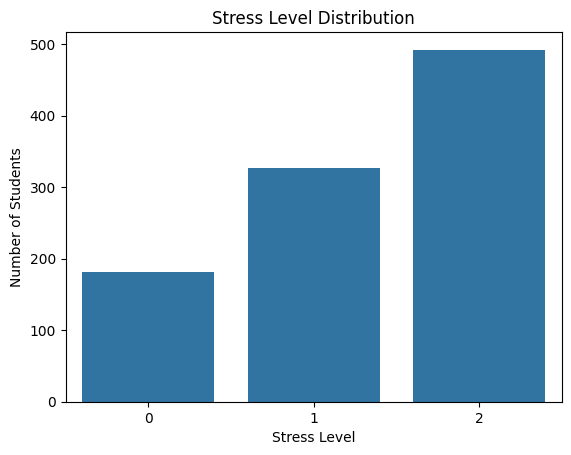

In [ ]:
# Count students in each stress category
sns.countplot(
    x='Stress Level',
    data=df
)

plt.title("Stress Level Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")
plt.show()

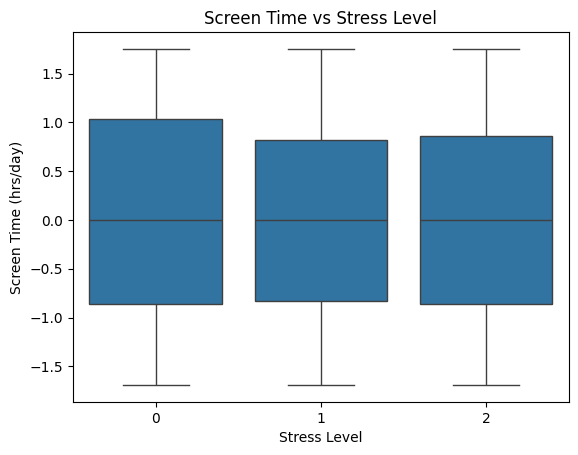

In [ ]:
# Boxplot for screen time vs stress
sns.boxplot(
    x='Stress Level',
    y='Screen Time (hrs/day)',
    data=df
)

plt.title("Screen Time vs Stress Level")
plt.show()

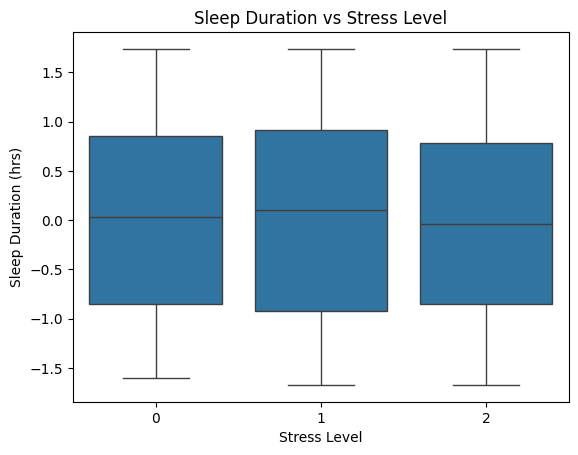

In [ ]:
# Boxplot for sleep duration and stress
sns.boxplot(
    x='Stress Level',
    y='Sleep Duration (hrs)',
    data=df
)

plt.title("Sleep Duration vs Stress Level")
plt.show()

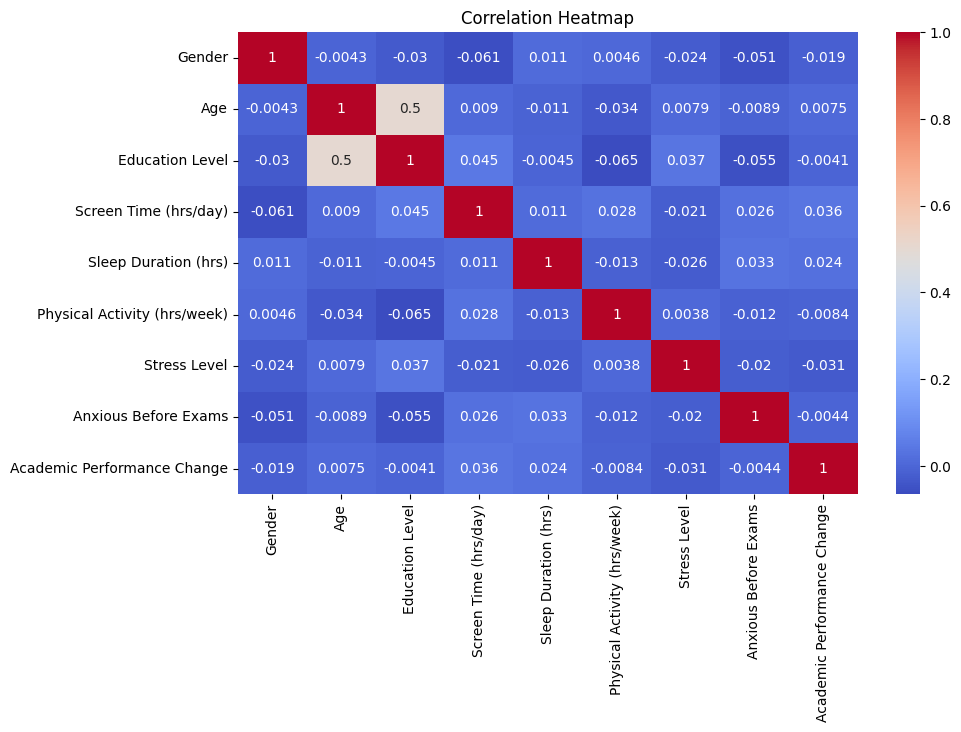

In [ ]:
# Show relationship between variables
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

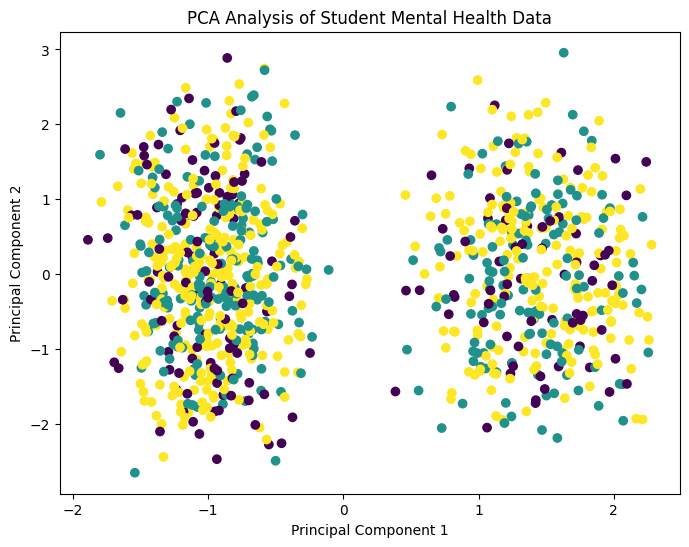

Explained Variance Ratio:
[0.18969069 0.13839821]


In [ ]:
# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Stress Level']
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Analysis of Student Mental Health Data")
plt.show()

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Features and target
X = df.drop("Stress Level", axis=1)
y = df["Stress Level"]

# Split + train + predict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.49
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        34
           1       0.00      0.00      0.00        68
           2       0.49      1.00      0.66        98

    accuracy                           0.49       200
   macro avg       0.16      0.33      0.22       200
weighted avg       0.24      0.49      0.32       200



In [ ]:
# Select features for clustering
X = df[['Screen Time (hrs/day)', 'Sleep Duration (hrs)']]

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# Fit model and assign cluster labels
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Display first few rows
print(df[['Screen Time (hrs/day)', 'Sleep Duration (hrs)', 'Cluster']].head(10))

   Screen Time (hrs/day)  Sleep Duration (hrs)  Cluster
0               0.065665              1.671040        2
1              -1.242131             -0.989852        0
2               0.891641             -0.716940        0
3               1.339045             -0.580484        2
4              -1.414209             -0.716940        0
5               0.581900              1.329900        2
6              -1.138884              0.101796        1
7               0.031249             -1.194536        0
8              -0.725896             -0.989852        0
9               0.685147              1.329900        2


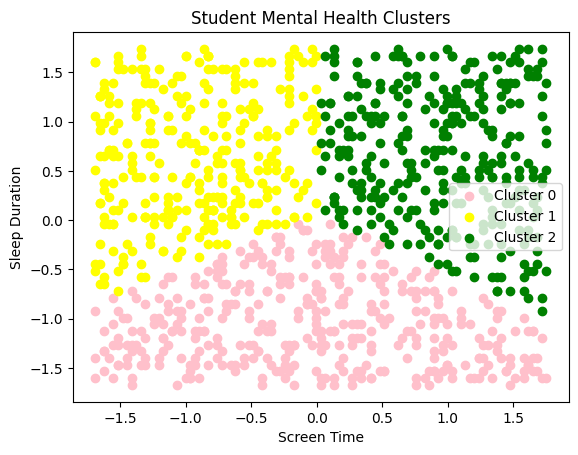

In [ ]:
# Select features and scale
X = df[['Screen Time (hrs/day)', 'Sleep Duration (hrs)']]
X_scaled = StandardScaler().fit_transform(X)

# Apply KMeans
df['Cluster'] = KMeans(n_clusters=3, random_state=42).fit_predict(X_scaled)

# Plot each cluster separately
colors = ['pink', 'yellow', 'green']

for i in range(3):
    plt.scatter(
        X_scaled[df['Cluster'] == i, 0],
        X_scaled[df['Cluster'] == i, 1],
        c=colors[i],
        label=f'Cluster {i}'
    )

plt.xlabel("Screen Time")
plt.ylabel("Sleep Duration")
plt.title("Student Mental Health Clusters")
plt.legend()
plt.show()